In [16]:
#Ne time intervals based on Polegon nodes output
import numpy as np
import glob
from scipy.special import gammaln
import random
from scipy.optimize import minimize
import tskit
import pandas as pd
from scipy.stats import lognorm
n = 20  # Number of samples or lineages at start 
# N_e1 = 1500  # Effective population size in interval [0, T1]
# N_e2 = 500  # Effective population size in interval [T1, T2]
# N_e3 = 2500   # Effective population size in interval [T2, infinity]
def get_equal_count_time_bins(path_pattern="/space/s1/KaiyuanLi/Ne_estimate/whole_genome_smallN/result/polegon/output/nodes_*.txt", num_bins=26):
    """
    Read all node times from files matching path_pattern, and compute time intervals
    such that each interval has equal number of node times.

    Parameters:
    - path_pattern: str, glob pattern to locate the input text files.
    - num_bins: int, number of equal-count bins (default 20)

    Returns:
    - T: np.ndarray of shape (num_bins+1,), where
         T[0] = 0, T[1]..T[num_bins-1] are computed from quantiles, and T[-1] = +inf
    """
    # Step 1: Read all node times
    all_times = []
    for file in glob.glob(path_pattern):
        with open(file, 'r') as f:
            times = [float(line.strip()) for line in f if line.strip()]
            all_times.extend(times)  # Exclude zero times if any

    all_times = np.array(all_times)
    print(f'unique node time shape: {all_times.shape}')

    # Step 2: Compute quantile-based cutoffs
    quantile_cutoffs = np.quantile(all_times[all_times > 0], np.linspace(0, 1, num_bins, endpoint=True)[1:])

    # Step 3: Add 0 at the beginning and +inf at the end
    T = np.concatenate(([0.0], quantile_cutoffs))

    return all_times,T
all_times,Ne_T=get_equal_count_time_bins()
# Ne_T=np.array([0,300,350,20000])
print('Dividing the time intervals based on Polegon nodes output\n', Ne_T)


unique node time shape: (17862100,)
Dividing the time intervals based on Polegon nodes output
 [    0.           110.78772429   230.23451289   372.33392201
   552.69954876   771.99529394  1023.73427755  1305.7666754
  1617.1829053   1959.01496424  2335.18656371  2751.85280677
  3213.86380706  3727.18214296  4300.71389074  4945.38990355
  5674.80008769  6508.82347909  7477.07293781  8620.62832219
 10005.47660394 11714.21075425 13896.63209662 16820.6902347
 20956.27720265 74793.59056057]


In [ ]:
import numpy as np
import glob

def get_equal_count_time_bins_split(
        path_pattern="/space/s1/KaiyuanLi/Ne_estimate/whole_genome_smallN/result/polegon/output/nodes_*.txt",
        num_bins=26):

    # Step 1: list and sort files
    files = sorted(glob.glob(path_pattern))
    n = len(files)
    mid = n // 2

    files_first = files[:mid]
    files_last = files[mid:]

    def load_times(file_list):
        times = []
        for file in file_list:
            with open(file, 'r') as f:
                times.extend(float(line.strip()) for line in f if line.strip())
        return np.array(times)

    # Step 2: load times
    times_first = load_times(files_first)
    times_last = load_times(files_last)

    print(f'first 50% times shape: {times_first.shape}')
    print(f'last 50% times shape: {times_last.shape}')

    # Step 3: compute bins from all times combined
    all_times = np.concatenate([times_first, times_last])

    quantile_cutoffs = np.quantile(
        all_times[all_times > 0],
        np.linspace(0, 1, num_bins, endpoint=True)[1:]
    )

    T = np.concatenate(([0.0], quantile_cutoffs))

    return times_first, times_last, T
times_first, times_last, Ne_T = get_equal_count_time_bins_split()

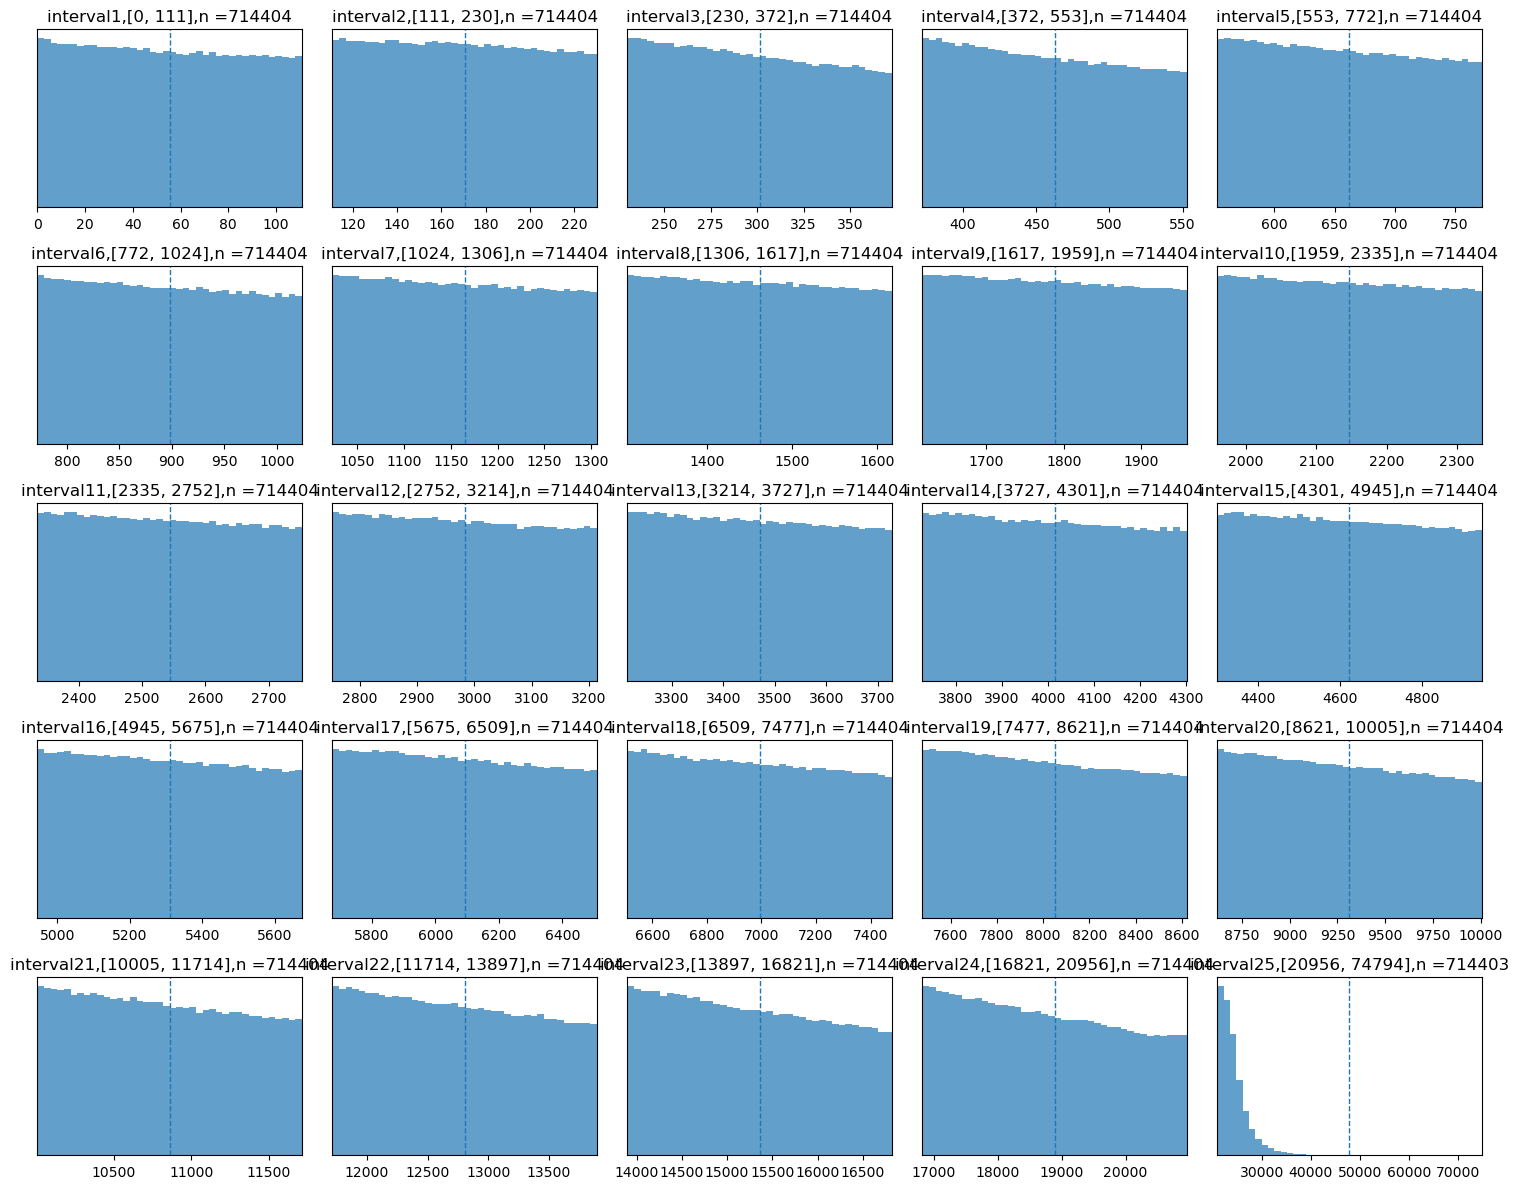

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def histogram_per_interval_raw(all_times, T, bins=40):
    times = all_times[all_times > 0]
    n_intervals = len(T) - 1

    fig, axes = plt.subplots(5, 5, figsize=(15, 12))
    axes = axes.flatten()

    for i in range(n_intervals):
        left, right = T[i], T[i+1]
        mask = (times >= left) & (times < right)
        subset = times[mask]

        axes[i].hist(subset, bins=bins, alpha=0.7)
        axes[i].axvline((left + right)/2, linestyle="--", linewidth=1)

        axes[i].set_xlim(left, right)
        axes[i].set_title(f"interval{i+1},[{left:.0f}, {right:.0f}],n ={len(subset)}")
        axes[i].set_yticks([])

    plt.tight_layout()
    plt.show()
histogram_per_interval_raw(all_times, Ne_T)

In [2]:
def get_fixed_time_bins_from_ne_breaks(ne_breaks):
    """
    Generate fixed time bins using the smallest interval length
    from given Ne interval breakpoints.
    
    - ne_breaks: array of breakpoints (increasing)
    - until the second-to-last breakpoint
    """
    ne_breaks = np.array(ne_breaks)
    
    # compute interval lengths
    intervals = np.diff(ne_breaks)
    min_len = int(round(np.min(intervals)))  
    
    # upper limit is second-to-last breakpoint
    upper = ne_breaks[-1]

    # generate fixed bins from 0 to upper
    fixed_bins = np.arange(0, upper+min_len , min_len)

    # append +inf
    

    return fixed_bins


# # ===== Example =====

def get_fixed_time_bins(num_bins=100, bin_size=50):
    """
    Return fixed equal-length bins, independent of the data.
    Example: 0, 50, 100, ..., 1000, +inf
    """
    # [0, 50, ..., num_bins*bin_size]
    bin_edges = np.arange(0, num_bins * bin_size + 1, bin_size)
    # Add +inf
    return bin_edges

# Example
# T_fixed = get_fixed_time_bins()

T_fixed = get_fixed_time_bins_from_ne_breaks(Ne_T)
print("Fixed bins based on min Ne interval, first 10:\n", T_fixed)
print(len(T_fixed)-1, " intervals in total.")


Fixed bins based on min Ne interval, first 10:
 [    0.   116.   232.   348.   464.   580.   696.   812.   928.  1044.
  1160.  1276.  1392.  1508.  1624.  1740.  1856.  1972.  2088.  2204.
  2320.  2436.  2552.  2668.  2784.  2900.  3016.  3132.  3248.  3364.
  3480.  3596.  3712.  3828.  3944.  4060.  4176.  4292.  4408.  4524.
  4640.  4756.  4872.  4988.  5104.  5220.  5336.  5452.  5568.  5684.
  5800.  5916.  6032.  6148.  6264.  6380.  6496.  6612.  6728.  6844.
  6960.  7076.  7192.  7308.  7424.  7540.  7656.  7772.  7888.  8004.
  8120.  8236.  8352.  8468.  8584.  8700.  8816.  8932.  9048.  9164.
  9280.  9396.  9512.  9628.  9744.  9860.  9976. 10092. 10208. 10324.
 10440. 10556. 10672. 10788. 10904. 11020. 11136. 11252. 11368. 11484.
 11600. 11716. 11832. 11948. 12064. 12180. 12296. 12412. 12528. 12644.
 12760. 12876. 12992. 13108. 13224. 13340. 13456. 13572. 13688. 13804.
 13920. 14036. 14152. 14268. 14384. 14500. 14616. 14732. 14848. 14964.
 15080. 15196. 15312. 15428. 

In [ ]:
a_values = np.arange(0, n + 1)
b_values = np.arange(0,n + 1)

def safe_logsumexp(log_terms, signs=None):
    """
    Compute log(sum(signs[i] * exp(log_terms[i]))) stably.
    signs ∈ {+1, -1} or None.
    """

    log_terms = np.asarray(log_terms)

    if log_terms.size == 0:
        return -np.inf

    max_x = np.minimum(-2, np.max(log_terms))

    # all -inf
    if not np.isfinite(max_x):
        return -np.inf

    shifted = np.exp(log_terms - max_x)

    if signs is not None:
        shifted = shifted * signs

    s = shifted.sum()

    # cancellation or invalid result, numerical issues can occur here, when all terms are extremmely small
    if s <= 0:
        return -np.inf
    # if not np.isfinite(s) or s <= 0:
    #     print("⚠️ invalid log detected")
    #     print("  max_x =", max_x)
    #     print("  s     =", s)
    #     print(log_terms)
    #     print(signs)
    return max_x + np.log(s)



# Efficiently calculate rising factorial in log space

def log_rising_factorial(a, b):
    if b == 0 or a==0:
        return 0
    if a < b:
        return 0  
    return np.sum([np.log(a - i) for i in range(b)])

# Efficiently calculate falling factorial in log space
def log_falling_factorial(a, n):
    if n == 0 or a==0:
        return 0
    return np.sum([np.log(a + i) for i in range(n)])

# Generate dataframes for rising and falling factorials
def create_factorial_dataframes(a_values, b_values):
    rising_data = {
        f'a[{b}]': [log_rising_factorial(a, b) for a in a_values] for b in b_values
    }
    falling_data = {
        f'a_{n}': [log_falling_factorial(a, n) for a in a_values] for n in b_values
    }
    df_rising = pd.DataFrame(rising_data, index=a_values)
    df_falling = pd.DataFrame(falling_data, index=a_values)
    return df_rising, df_falling

# Function to calculate "choose 2 out of k" (k choose 2)
def choose_2_out_of_k(k):
    if k < 2:
        return 0
    return k*(k-1)/2
C1 = np.array([choose_2_out_of_k(k) for k in range(n + 1)])


df_rising, df_falling = create_factorial_dataframes(a_values, b_values)  



def logconstant_tables_Anp(n,Ne=1,t=1):
    signs_arr = np.empty((n + 1, n + 1), dtype=object)
    log_factorial=np.empty((n + 1, n + 1), dtype=object)
    exp_arr=np.empty((n + 1, n + 1), dtype=object)
    logbk=np.empty((n+1), dtype=object)
    ck=np.empty(n )
    for k_start in range(1,n+1):
        logbk_temp=[]
        for k_end in range(1,k_start+1):
            log_terms= []
            signs=[]
            exp_term=[]
            ck[k_end-1]=-C1[k_end]*t/2
            logbk_temp.append(df_rising.iloc[k_start, k_end]-df_falling.iloc[k_start, k_end]+np.log(2*k_end-1))
            for k in range(k_end, k_start + 1):
                # Numerator and denominator in log space
                numerator = (
                    np.log(2 * k - 1)
                    + df_falling.iloc[k_end, k - 1]
                    + df_rising.iloc[k_start, k]
                )

                denominator = (
                gammaln(k_end + 1)  # log(k_end!)
                + gammaln(k - k_end + 1)  # log((k - k_end)!)
                + df_falling.iloc[k_start, k]
                )
                signs.append(1-2*((k - k_end)%2))
                log_terms.append(numerator - denominator)
                exp_term.append(-C1[k]*t/2/Ne)

            signs_arr[k_start, k_end] = np.array(signs)
            log_factorial[k_start, k_end] = np.array(log_terms)
            exp_arr[k_start, k_end] = np.array(exp_term)
            logbk[k_start]=np.array(logbk_temp)
    return signs_arr, log_factorial,exp_arr,logbk,ck

signs_arr, log_factorial,exp_arr,logbk,ck = logconstant_tables_Anp(n)

def Ant_p(Ne,k_start, k_end,t):
    log_terms=exp_arr[k_start,k_end]*t/Ne+log_factorial[k_start,k_end]
    signs=signs_arr[k_start,k_end]
    # Combine positive and negative parts safely
    log_inner_sum = safe_logsumexp(log_terms,signs=signs)
    return log_inner_sum

def dynamic_programming(n, Ne,T):
    t=np.array(T[1:]) - np.array(T[:-1])  # Time intervals
    num_interval = len(t)
    max_sum = n - 1

    # Initialize log_dp table: all -inf, except base case
    log_dp = np.full((max_sum + 1, num_interval), -np.inf)
    log_dp[0][0] = 0.0  # log(1) = 0

    # Fill log_dp table
    for i in range(1, num_interval):
        for s in range(max_sum + 1):
            terms = []
            for j in range(s + 1):
                log_prev = log_dp[s - j][i - 1]
                if np.isneginf(log_prev):
                    continue
                ant_val = Ant_p(Ne[i - 1], n - (s - j), n - s, t[i - 1])
                log_term = log_prev + ant_val
                terms.append(log_term)
            if terms:
                log_dp[s][i] = safe_logsumexp(np.array(terms))

    return log_dp
def dp_to_p(log_dp, n):
    dp = np.exp(log_dp)
    cdf = np.cumsum(dp, axis=0)
    p_interval = np.zeros((n - 1, dp.shape[1]))
    p_interval[:, 0] = 1 - cdf[:n - 1, 1]
    p_interval[:, 1:-1] = cdf[:n - 1, 1:-1] - cdf[:n - 1, 2:]
    p_interval[:, -1] = cdf[:n - 1, -1]
    return np.clip(p_interval, 0, 1)
def safe_normalize_log(log_numeric_table, axis=0):
    """
    Stable normalization (softmax) along given axis.
    log_numeric_table: array of log-values.
    """
    # max over axis to stabilize
    max_log = np.max(log_numeric_table, axis=axis, keepdims=True)
    shifted = log_numeric_table - max_log
    exp_shifted = np.exp(shifted)
    denom = np.sum(exp_shifted, axis=axis, keepdims=True)+1e-300  # avoid division by zero
    return exp_shifted / denom



In [20]:
#LOAD INPUT DATA
# ==========================================================
ref_file = "/space/s1/KaiyuanLi/Ne_estimate/whole_genome_smallN/result/polegon/ARGs/ts_poly_101.trees"
ts_ref = tskit.load(ref_file)
span = np.load(f"/space/s1/KaiyuanLi/Ne_estimate/whole_genome_smallN/result/polegon/ARGs/span.npy")
span_rate = span / np.sum(span)
time = np.load(f"/space/s1/KaiyuanLi/Ne_estimate/whole_genome_smallN/result/polegon/ARGs/time.npy")

# # MLE parameters for lognormal
# mu_log = np.mean(log_time, axis=2)
# sigma_log = np.std(log_time, axis=2)
# # Inflate variance by 1.5 in log-space
mu = np.load(f"/space/s1/KaiyuanLi/Ne_estimate/whole_genome_smallN/result/polegon/ARGs/logmu_vec.npy")
sigma = np.load(f"/space/s1/KaiyuanLi/Ne_estimate/whole_genome_smallN/result/polegon/ARGs/logsigma_vec.npy")
# mu, sigma = np.mean(time, axis=2), np.std(time, axis=2)
inflation = 1
sigma_inflated = sigma * np.sqrt(inflation)



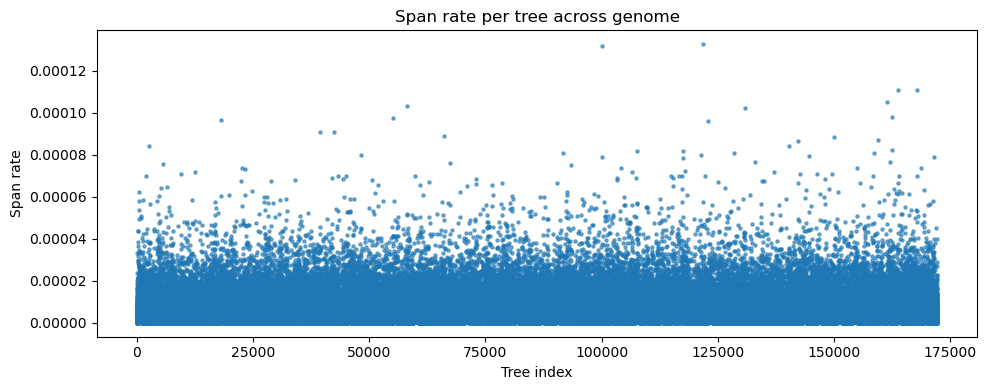

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_span_rate_vs_index(span_rate):
    n = len(span_rate)

    plt.figure(figsize=(10, 4))
    plt.scatter(np.arange(n), span_rate, s=5, alpha=0.6)
    plt.xlabel("Tree index")
    plt.ylabel("Span rate")
    plt.title("Span rate per tree across genome")
    plt.tight_layout()
    plt.show()
plot_span_rate_vs_index(span_rate)

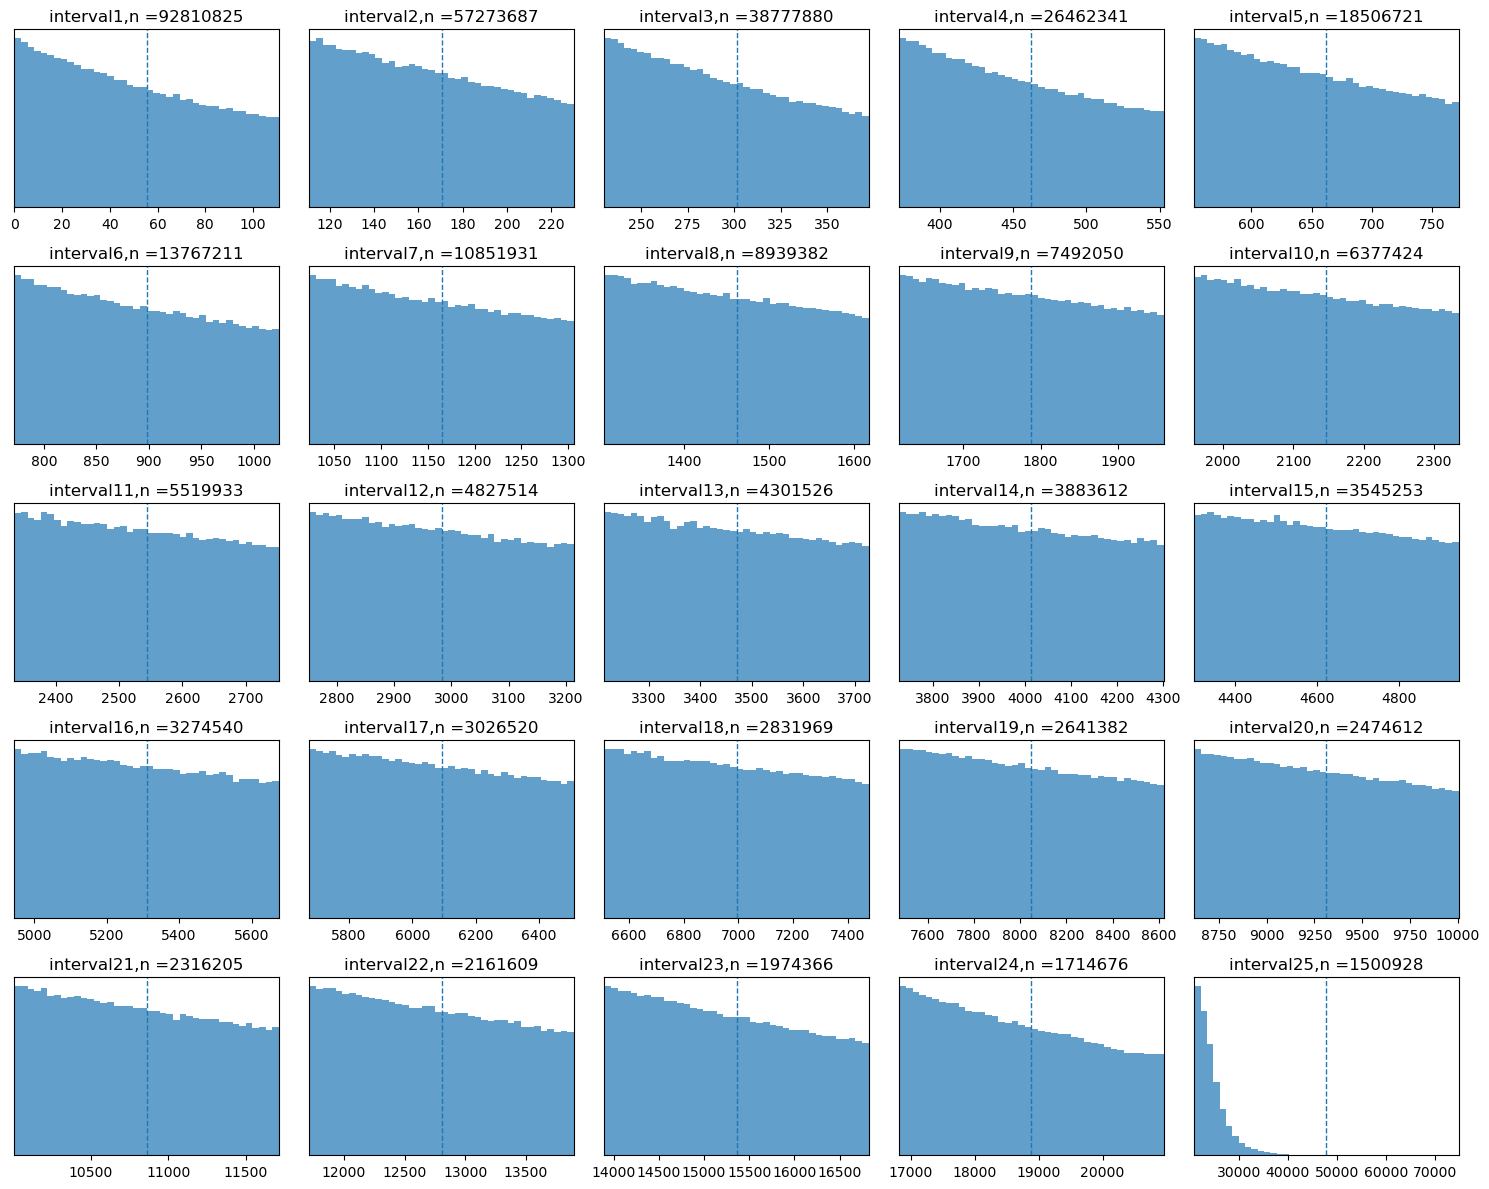

In [37]:
vals = time.reshape(-1)
import numpy as np
import matplotlib.pyplot as plt

def histogram_per_interval_raw(all_times, T, bins=40):
    times = all_times[all_times > 0]
    n_intervals = len(T) - 1

    fig, axes = plt.subplots(5, 5, figsize=(15, 12))
    axes = axes.flatten()

    for i in range(n_intervals):
        left, right = T[i], T[i+1]
        mask = (times >= left) & (times < right)
        subset = times[mask]

        axes[i].hist(subset, bins=bins, alpha=0.7)
        axes[i].axvline((left + right)/2, linestyle="--", linewidth=1)

        axes[i].set_xlim(left, right)
        axes[i].set_title(f"interval{i+1},n ={len(subset)}")
        axes[i].set_yticks([])

    plt.tight_layout()
    plt.show()
histogram_per_interval_raw(vals, Ne_T)

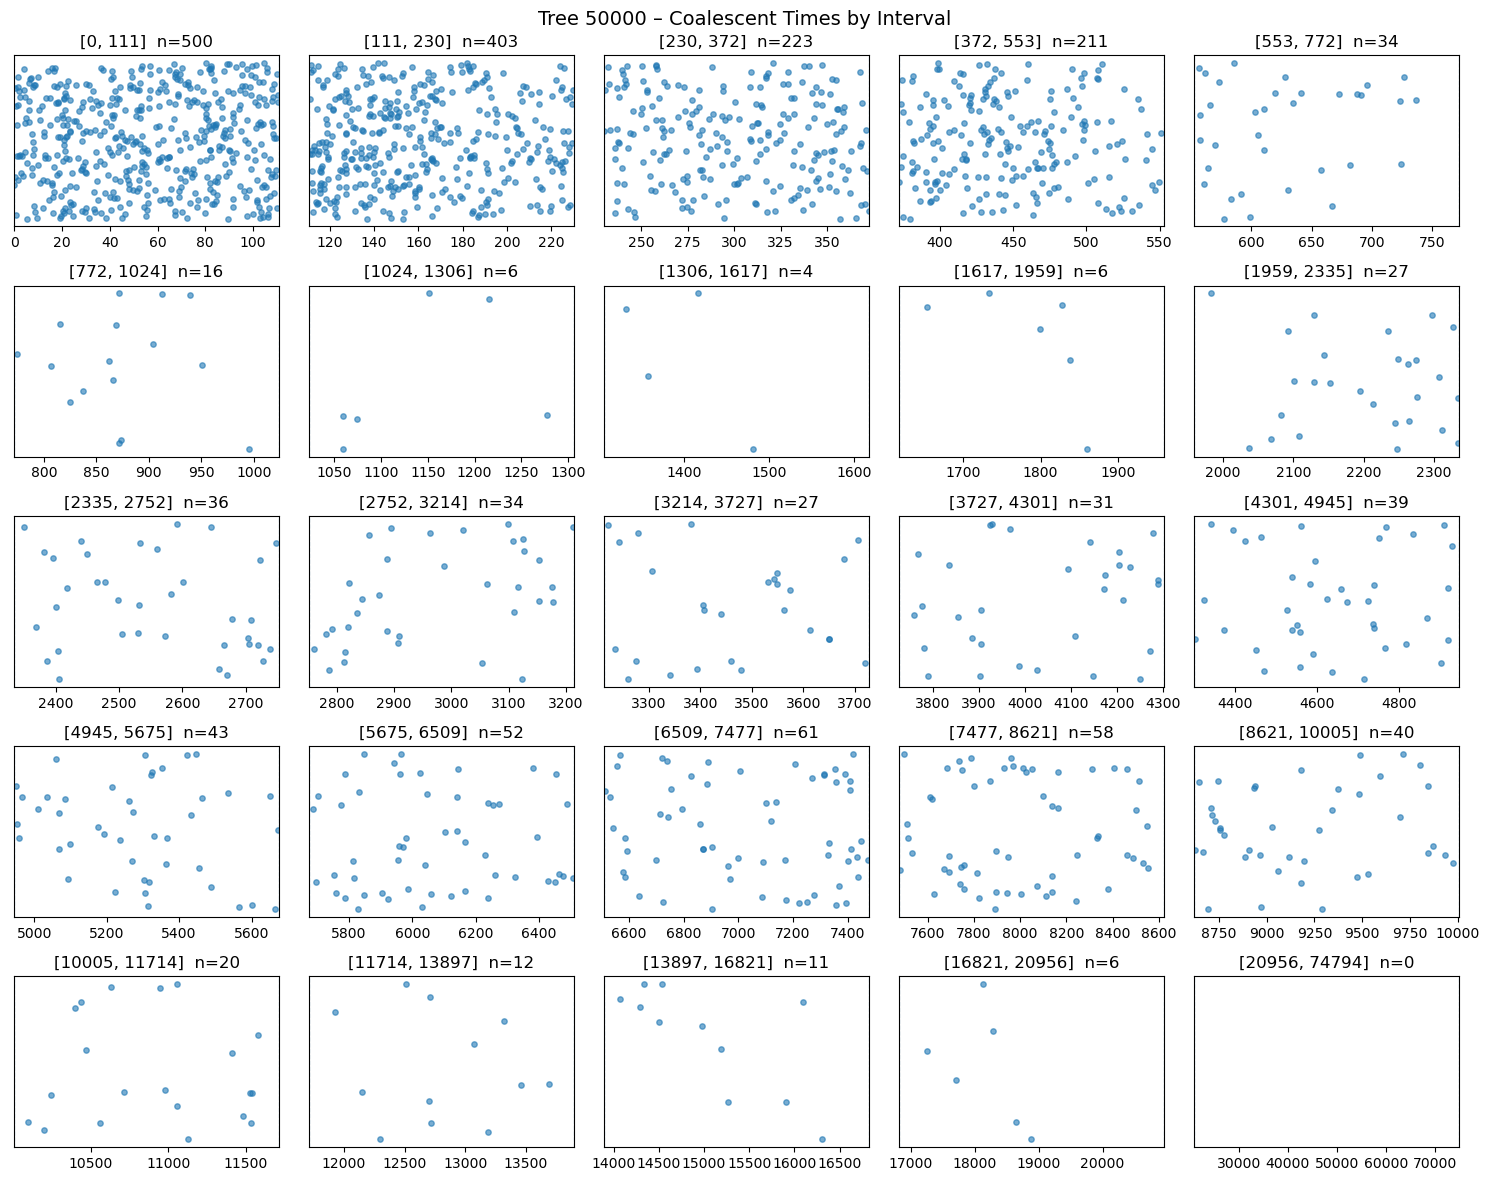

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def scatter_tree_per_interval(time, T, tree_idx):
    """
    Scatter coalescent times of ONE tree in each interval.
    
    time shape: (19, n_trees, 100)
    T: interval boundaries
    tree_idx: which tree to visualize
    """
    T = np.asarray(T)
    n_intervals = len(T) - 1

    # extract this tree's coalescent times
    vals = time[:, tree_idx, :].reshape(-1)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]

    fig, axes = plt.subplots(5, 5, figsize=(15, 12))
    axes = axes.flatten()

    for i in range(n_intervals):
        left, right = T[i], T[i+1]
        subset = vals[(vals >= left) & (vals < right)]

        y = np.random.uniform(0, 1, size=len(subset))

        axes[i].scatter(subset, y, s=15, alpha=0.6)
        axes[i].axvline(left, linestyle="--", linewidth=0.8)
        axes[i].axvline(right, linestyle="--", linewidth=0.8)

        axes[i].set_xlim(left, right)
        axes[i].set_yticks([])
        axes[i].set_title(f"[{left:.0f}, {right:.0f}]  n={len(subset)}")

    plt.suptitle(f"Tree {tree_idx} – Coalescent Times by Interval", fontsize=14)
    plt.tight_layout()
    plt.show()
scatter_tree_per_interval(time, Ne_T, tree_idx=50000)

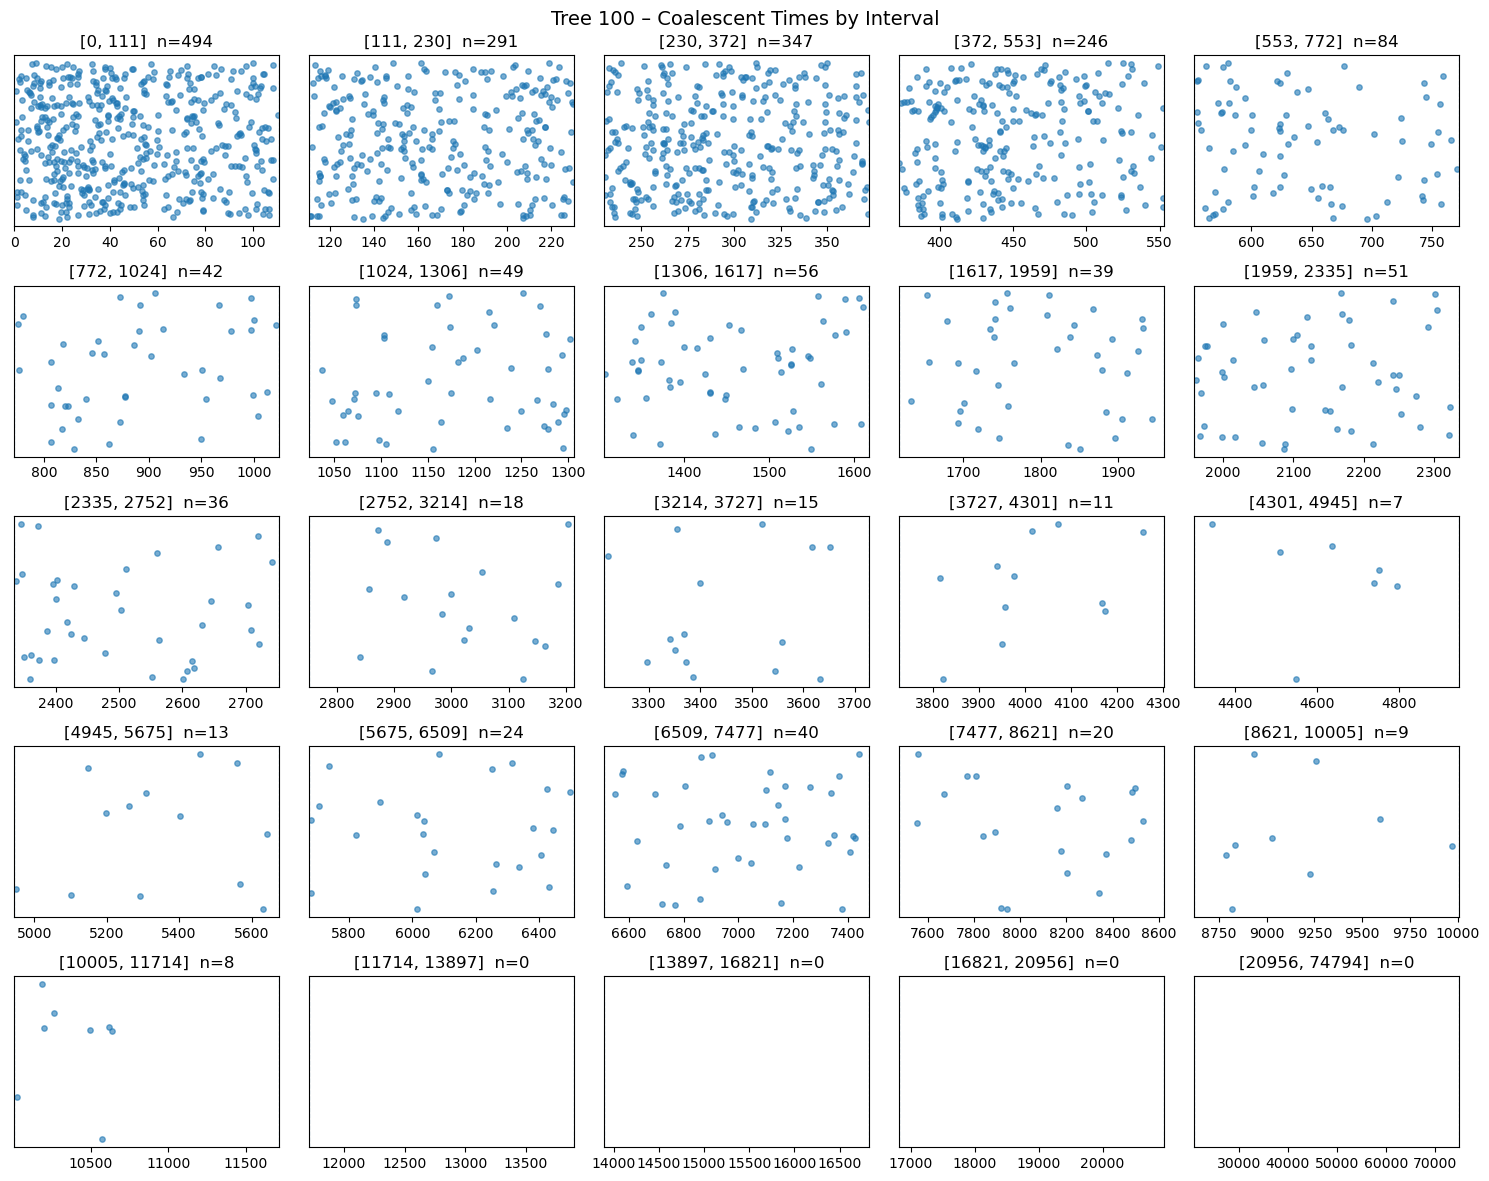

In [25]:
scatter_tree_per_interval(time, Ne_T, tree_idx=100)

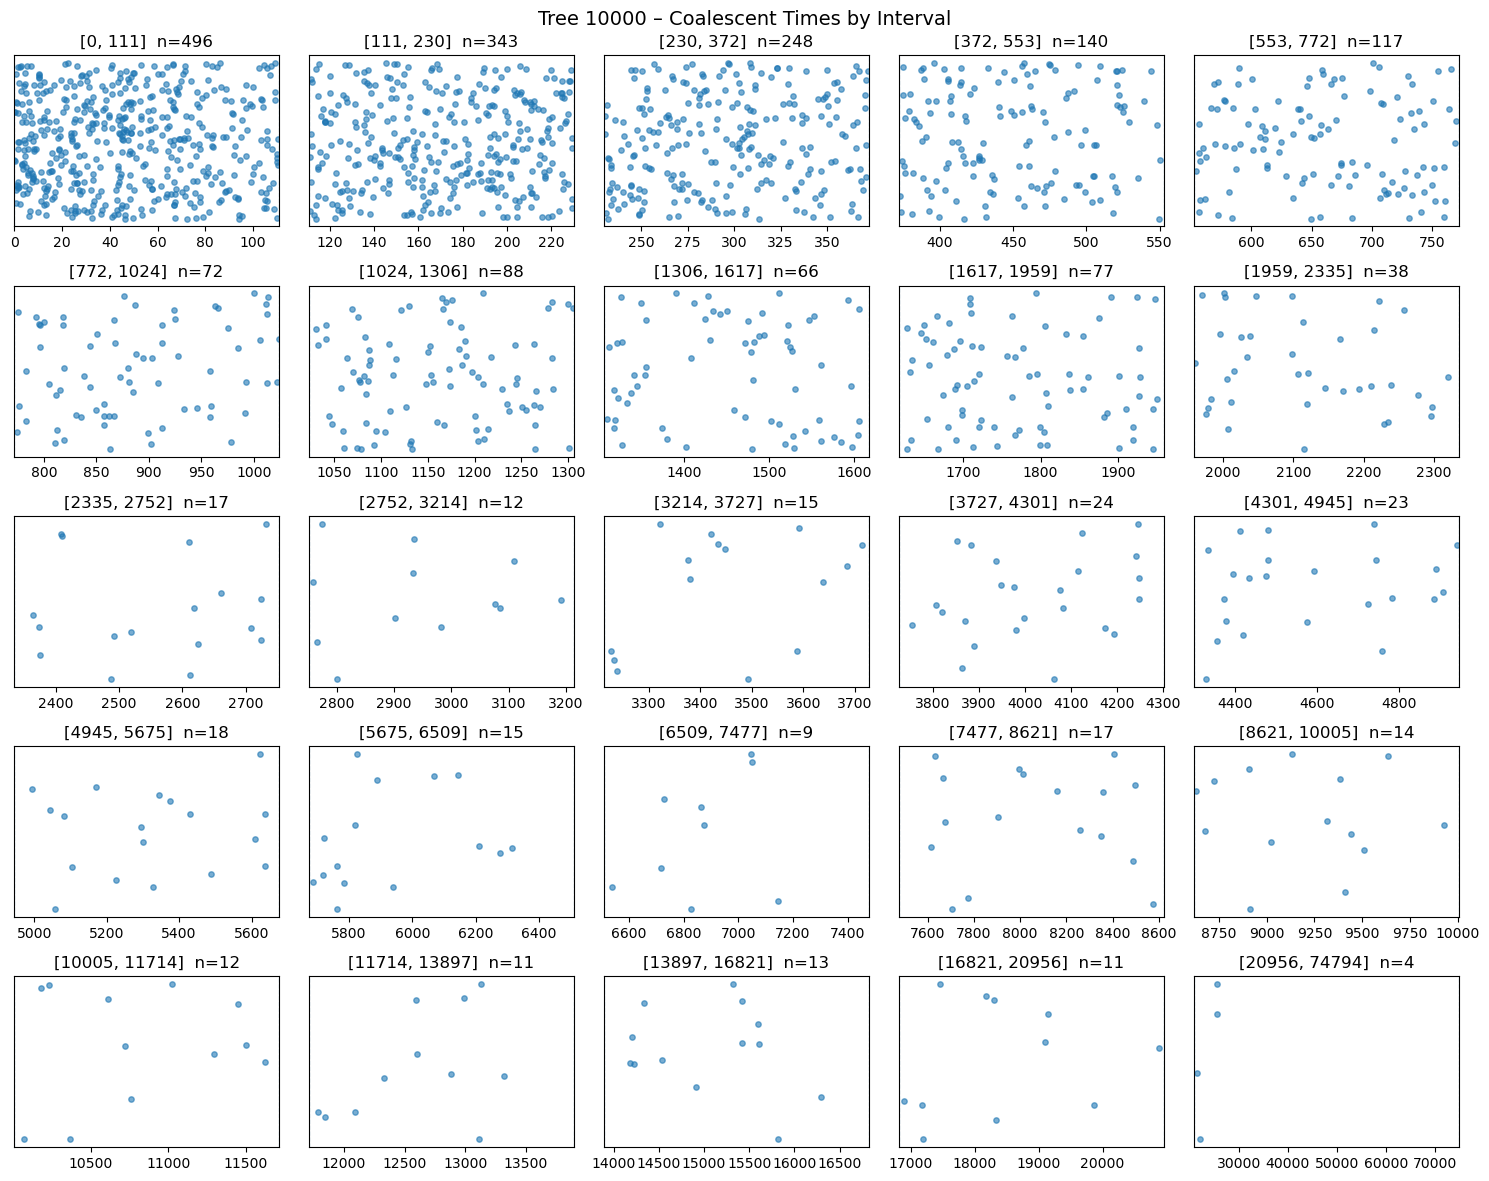

In [27]:
scatter_tree_per_interval(time, Ne_T, tree_idx=10000)

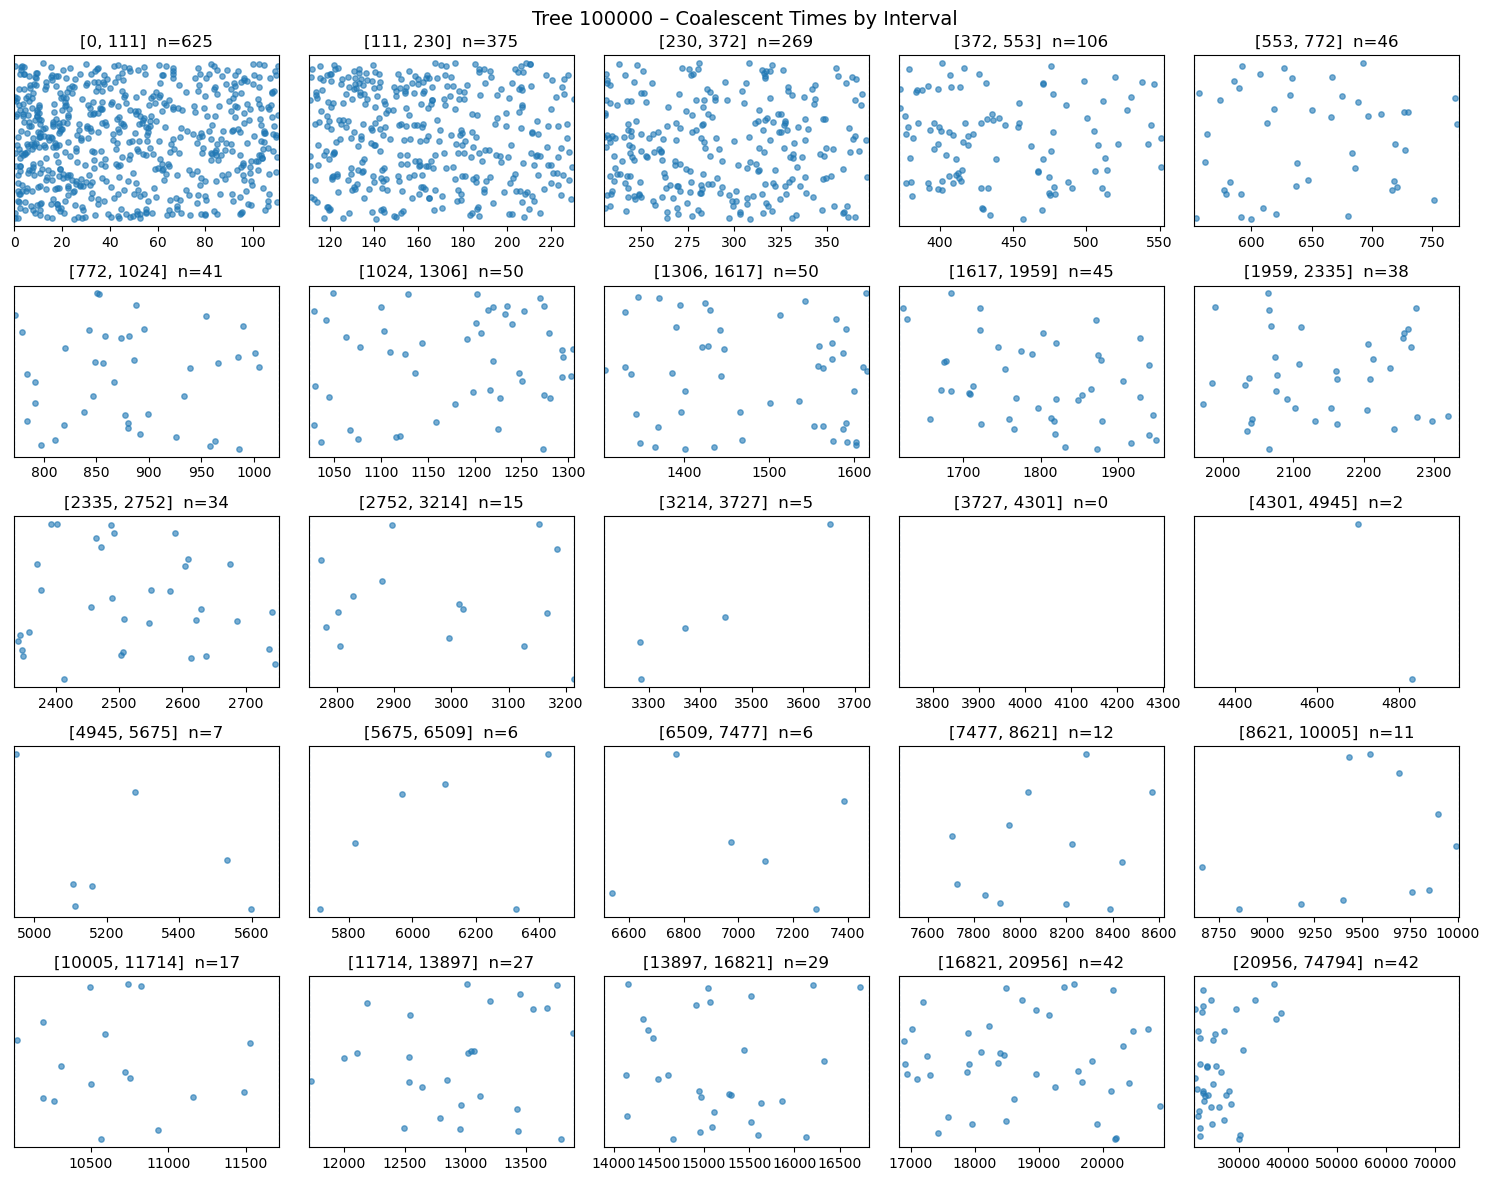

In [28]:
scatter_tree_per_interval(time, Ne_T, tree_idx=100000)

In [7]:
def interval_midpoints(T):
    """
    Compute midpoints of each finite interval.

    Parameters
    ----------
    T : ndarray, shape (m,)
        Interval boundaries. The last element may be np.inf.

    Returns
    -------
    mids : ndarray, shape (m-2,)
        Midpoints of each finite interval (exclude (T, +inf)).
    """
    T = np.asarray(T)
    mids = (T[:-1] + T[1:]) / 2.0
    return mids

middle_time_point=interval_midpoints(T_fixed)
# Compute log pdf for each midpoint

# logpdf_mat = norm.logpdf(middle_time_point[:, None, None], loc=mu[None, :, :], scale=sigma_inflated[None, :, :] )
    
# logpdf_mat =lognorm.logpdf(middle_time_point[:, None, None] , s=sigma_inflated[None, :, :], scale=np.exp(mu[None, :, :]))
# np.save(f"/space/s1/KaiyuanLi/Ne_estimate/whole_genome_smallN/result/polegon/ARGs/logpdf_mat.npy", logpdf_mat)
logpdf_mat = np.load(f"/space/s1/KaiyuanLi/Ne_estimate/whole_genome_smallN/result/polegon/ARGs/logpdf_mat.npy")

In [96]:
def fused_lasso_logNe_smooth(Ne, lam_tv, eps=1e-6):
    """
    Smooth TV penalty on log(Ne):
      lam * sum_k sqrt( (logNe[k+1]-logNe[k])^2 + eps )
    """
    logNe = np.log(Ne)
    d = np.diff(logNe)
    return lam_tv * np.sum(np.sqrt(d*d + eps))

def objective_before_last(Ne, n_all, n, span_rate, Ne_T):
    """
    Numerically stable log-space objective.
    """
    # 1) 动态规划算出 p_ki
    dp_temp = dynamic_programming(n, Ne, Ne_T)
    table = dp_to_p(dp_temp, n)      # shape ~ (num_intervals, n-1)

    # 2) log p，允许出现 -inf（p=0 的地方）
    logp = np.log(table)

    # 3) 权重（你之前叫 log_contrib，其实不是 log）
    #    shape 要和 logp 对得上，这里沿着 tree 方向 sum 掉
    weight = np.sum(n_all * span_rate[None, :, None], axis=1).T

    # 4) 元素级贡献：weight * logp
    contrib = weight * logp

    # 5) 处理 0 * -inf 产生的 nan：极限是 0，所以把 nan 变成 0
    #    注意这里不要改 neginf / posinf，只改 nan
    contrib = np.where(np.isnan(contrib), 0.0, contrib)

    total_log = np.sum(contrib)
    penalty = fused_lasso_logNe_smooth(Ne, lam_tv=0.001)

    return -total_log + penalty

def estimate_last_Ne(col3, time, span_rate, T2):
    time_tree = np.mean(time, axis=2)
    weighted = col3 * time_tree / np.sum(col3, axis=0)
    adjusted = np.clip(np.sum(weighted, axis=0) , a_min=0, a_max=None)

    # only use positive values
    pos = adjusted > T2

    # if all zeros, return 0 (or something else)
    if not np.any(pos):
        return -T2   # or return 0

    # renormalize span_rate
    sr = span_rate[pos]
    sr = sr / np.sum(sr)

    # weighted average of only positive adjusted values
    weighted_mean = np.sum(adjusted[pos] * sr)

    return weighted_mean-T2 


In [89]:
# Map midpoints to Ne intervals
def map_midpoints_to_ne_intervals(midpoints, Ne_T):
    """
    midpoints: array of shape (M,)
    Ne_T: breakpoints of Ne intervals, shape (K,)
          assumed sorted and includes +inf
    Returns:
        mapping: array of length M
                 each entry is interval index in [0, K-2]
    """

    # find index j where Ne_T[j] <= mid < Ne_T[j+1]
    mapping = np.searchsorted(Ne_T, midpoints, side='right') - 1
    return mapping
mapping = map_midpoints_to_ne_intervals(middle_time_point, Ne_T)

In [9]:
max_iter = 100
tolerance = len(Ne_T)*0.1
# Initial Ne values
Ne_vec=np.repeat(1000.0, len(Ne_T)-1)
print("Initial Ne values:", Ne_vec)
results = []
for it in range(max_iter):
    # ------------------------------
    # 1) Dynamic programming + pki
    # ------------------------------
    Ne_values = Ne_vec[mapping]
   
    dp = dynamic_programming(n, Ne_values, T_fixed)
    pki = dp_to_p(dp, n)

    # ------------------------------
    # 2) Vectorized computation over all trees
    # ------------------------------
    logpki = np.log(pki.T)                            # (num_intervals, n-1)
    log_numeric_table = logpdf_mat.swapaxes(1, 2) + logpki[:, None, :]  # (m, num_trees, n-1)

    # Normalize safely across intervals (axis=0)
    normalized = safe_normalize_log(log_numeric_table, axis=0)  


    n_stack=np.stack([normalized[mapping == k].sum(axis=0) 
                 for k in np.unique(mapping)])
    # ------------------------------
    # 3) Joint optimization of Ne1 and Ne2
    # ------------------------------
    def joint_objective(x):
        Ne_val = x
        val = objective_before_last(Ne_val, n_stack, n, span_rate, Ne_T)

        # ---- DEBUG CHECK HERE ----
        if np.isnan(val) or np.isinf(val):
            print("\n⚠️ NaN/inf detected in objective!")
            print("  Ne_val:", Ne_val)
            print("  objective_before_last =", val)
        # -------------------------

        return val


    res = minimize(
    joint_objective,
    x0=Ne_vec[:-1],
    method="L-BFGS-B",
    bounds=[(300, 5000)] * len(Ne_vec[:-1]),
    options={"ftol": 1e-10, "gtol": 1e-10, "maxiter": 1000})


    Ne_vec_new = res.x
    joint_loss = res.fun

    Nelast = estimate_last_Ne(normalized[mapping == np.max(mapping)].sum(axis=0).T, time, span_rate, Ne_T[-2])
    delta = abs(Ne_vec_new - Ne_vec[:-1]).sum()+abs(Nelast - Ne_vec[-1])
    

    Ne_vec[:-1] = Ne_vec_new
    Ne_vec[-1] = Nelast
    print(Ne_vec,joint_loss)
    results.append((Ne_vec.copy(), joint_loss))
    if delta < tolerance:
        break


Initial Ne values: [1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.]


/tmp/ipykernel_1409651/512889134.py:19: RuntimeWarning: divide by zero encountered in log
  logpki = np.log(pki.T)                            # (num_intervals, n-1)
/tmp/ipykernel_1409651/57803340.py:10: RuntimeWarning: divide by zero encountered in log
  logp = np.log(table)
/tmp/ipykernel_1409651/57803340.py:17: RuntimeWarning: invalid value encountered in multiply
  contrib = weight * logp


[1124.53816265 1079.75381862 1361.25842312  956.06956342 1223.40684353
 1446.31134169 1104.95461807 1225.51524413 1356.00933224 1122.86150775
 1679.90420742 1106.36591472 1233.98395605 1356.85398241 1256.14860375
 1059.82858813 1179.82992324 1095.54944759 1067.17806367 1065.76122031
 1012.67099087  997.79447921  997.81358111 2277.71263209] 17.328465507992117
[1190.5520709  1126.98453025 1741.65070424  883.77031058 1427.62442545
 1907.92843575 1118.42914678 1372.26537337 1699.35344402 1150.74870867
 2428.89985492 1098.53079212 1395.20763681 1693.84251071 1461.5535335
 1019.70571728 1322.67651186 1139.99825806 1101.91963165 1127.48248067
 1012.74906465  988.89867513  992.49842355 2277.71255456] 17.84591477318937
[1218.79358034 1138.37434466 2172.23928164  807.45466038 1671.81606606
 2151.69489291 1137.25260298 1478.74926489 1803.82189693 1161.33664502
 2495.08503173 1082.81680505 1424.36120885 1732.81287872 1487.51693843
  991.81744186 1337.03615851 1141.33911285 1102.6607268  1132.33630

KeyboardInterrupt: 

In [97]:
max_iter = 100
tolerance = len(Ne_T)*0.1
# Initial Ne values
Ne_vec=np.repeat(1000.0, len(Ne_T)-1)
print("Initial Ne values:", Ne_vec)
results = []
for it in range(max_iter):
    # ------------------------------
    # 1) Dynamic programming + pki
    # ------------------------------
    Ne_values = Ne_vec[mapping]
   
    dp = dynamic_programming(n, Ne_values, T_fixed)
    pki = dp_to_p(dp, n)

    # ------------------------------
    # 2) Vectorized computation over all trees
    # ------------------------------
    logpki = np.log(pki.T)                            # (num_intervals, n-1)
    log_numeric_table = logpdf_mat.swapaxes(1, 2) + logpki[:, None, :]  # (m, num_trees, n-1)

    # Normalize safely across intervals (axis=0)
    normalized = safe_normalize_log(log_numeric_table, axis=0)  


    n_stack=np.stack([normalized[mapping == k].sum(axis=0) 
                 for k in np.unique(mapping)])
    # ------------------------------
    # 3) Joint optimization of Ne1 and Ne2
    # ------------------------------
    def joint_objective(x):
        Ne_val = x
        val = objective_before_last(Ne_val, n_stack, n, span_rate, Ne_T)

        # ---- DEBUG CHECK HERE ----
        if np.isnan(val) or np.isinf(val):
            print("\n⚠️ NaN/inf detected in objective!")
            print("  Ne_val:", Ne_val)
            print("  objective_before_last =", val)
        # -------------------------

        return val


    res = minimize(
    joint_objective,
    x0=Ne_vec[:-1],
    method="L-BFGS-B",
    bounds=[(300, 5000)] * len(Ne_vec[:-1]),
    options={"ftol": 1e-10, "gtol": 1e-10, "maxiter": 1000})


    Ne_vec_new = res.x
    joint_loss = res.fun

    Nelast = estimate_last_Ne(normalized[mapping == np.max(mapping)].sum(axis=0).T, time, span_rate, Ne_T[-2])
    delta = abs(Ne_vec_new - Ne_vec[:-1]).sum()+abs(Nelast - Ne_vec[-1])
    

    Ne_vec[:-1] = Ne_vec_new
    Ne_vec[-1] = Nelast
    print(Ne_vec,joint_loss)
    results.append((Ne_vec.copy(), joint_loss))
    if delta < tolerance:
        break


Initial Ne values: [1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.]


/tmp/ipykernel_1608832/512889134.py:19: RuntimeWarning: divide by zero encountered in log
  logpki = np.log(pki.T)                            # (num_intervals, n-1)
/tmp/ipykernel_1608832/3350905390.py:26: RuntimeWarning: invalid value encountered in multiply
  contrib = weight * logp


[1395.27694665 1171.7317803  1462.20910157 1180.79409643 1531.11162969
 2028.25572556 1567.80228931 1802.00206172 1927.81042769 1704.45215559
 2006.34378354 1639.21826585 1664.57834446 1678.46404301 1572.30870288
 1403.05375479 1415.86030561 1319.22848219 1255.57396002 1206.40812753
 1111.01491667 1042.2181808  1014.08246393 2277.69133713] 19.07399430041482
[1469.18051798 1249.60496492 1706.24900028 1119.92189136 2011.67916344
 2774.38585548 1713.94908398 2184.13398823 2379.30724701 1924.54689433
 2547.61033758 1866.41732714 1989.37281499 2061.00453847 1904.05346721
 1609.41295621 1683.91545255 1533.75651086 1444.09730125 1385.36467167
 1209.30978415 1077.75112287 1022.4448894  2277.68644066] 20.0071786975302
[1468.55371538 1258.60040696 1998.12737424 1070.02062159 2097.92710325
 2851.11046681 1669.10876261 2202.67805872 2416.44984341 1912.6427075
 2607.91860655 1867.92839716 2018.05785026 2103.93190285 1941.02778635
 1624.73101205 1715.85308861 1558.42964385 1468.41674878 1411.5360490